# 🌸 Iris Flower Classification

## Oasis Infobyte Data Science Internship – Task 1

### Objective
The objective of this project is to build machine learning classification models that can predict the species of an Iris flower based on its physical measurements.

The Iris dataset contains three species:
- Iris Setosa
- Iris Versicolor
- Iris Virginica

The classification is performed using features such as sepal length, sepal width, petal length, and petal width.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_iris

In [2]:
# Load the Iris dataset from scikit-learn
iris = load_iris()

# Create a DataFrame using the feature data
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target column
df["target"] = iris.target

# Convert numeric target values to species names
df["species"] = df["target"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

# Display the first five rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nTarget Classes:")
print(iris.target_names)

Dataset Shape: (150, 6)

Column Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target', 'species']

Target Classes:
['setosa' 'versicolor' 'virginica']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


In [6]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [7]:
df["species"].value_counts()

species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

### Pairplot Observation

The visualisation shows that the three Iris species can be differentiated based on their physical measurements. Petal length and petal width provide particularly clear separation between the species. Setosa is clearly separated, while Versicolor and Virginica show some overlap.

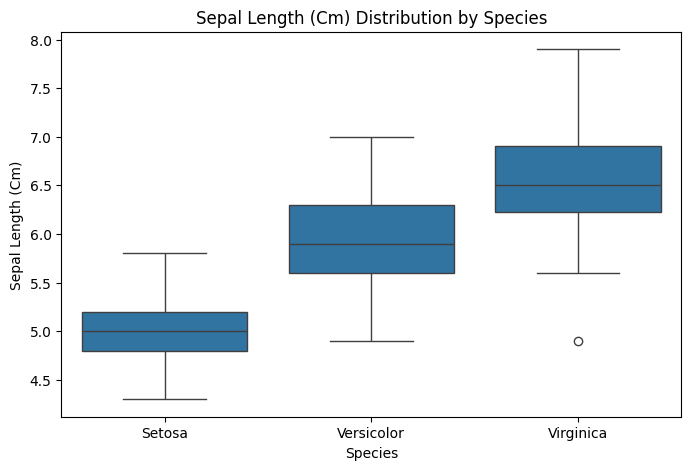

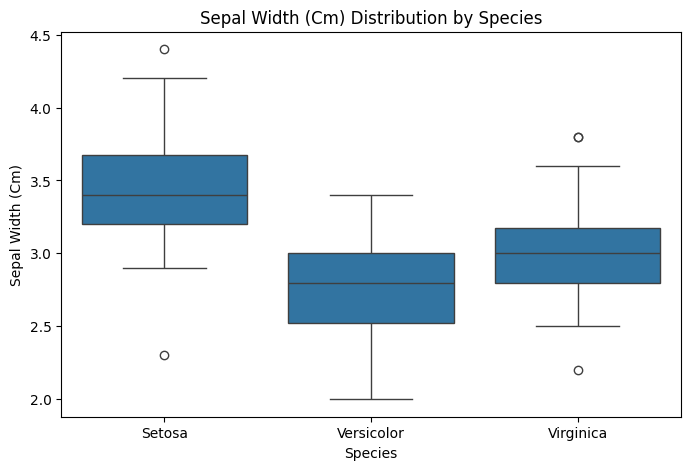

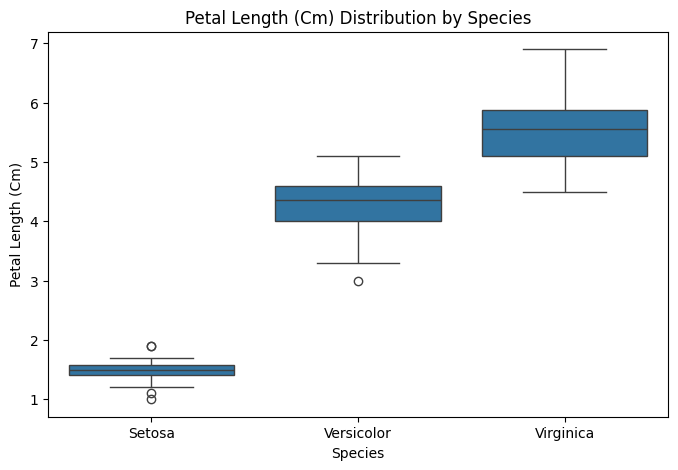

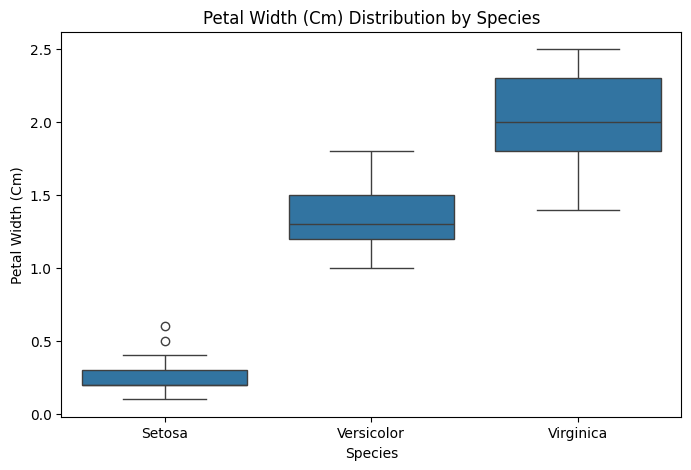

In [8]:
features = iris.feature_names

for feature in features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="species", y=feature)
    plt.title(f"{feature.title()} Distribution by Species")
    plt.xlabel("Species")
    plt.ylabel(feature.title())
    plt.show()

## Feature Selection Discussion

Based on the exploratory data analysis and visualisations, petal length and petal width appear to be the most discriminative features for classifying Iris species. These features show clearer separation between the different species, especially for Setosa.

Sepal length and sepal width also provide useful information but show more overlap between Versicolor and Virginica. For this project, all four features will be used initially to train the machine learning models, allowing the models to learn from the complete set of available measurements.

In [9]:
from sklearn.model_selection import train_test_split

# Features (X) - Use only the four measurement columns
X = iris.data

# Target (y)
y = iris.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (120, 4)
Testing Data Shape: (30, 4)


In [10]:
from sklearn.linear_model import LogisticRegression

# Create and train the model
logistic_model = LogisticRegression(max_iter=200)
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test)

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Create and train the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

In [12]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [13]:
def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)

    print(f"===== {model_name} =====")
    print(f"Accuracy: {accuracy:.4f}\n")

    print("Classification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=iris.target_names
    ))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=iris.target_names,
        yticklabels=iris.target_names
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    return accuracy

===== Logistic Regression =====
Accuracy: 0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



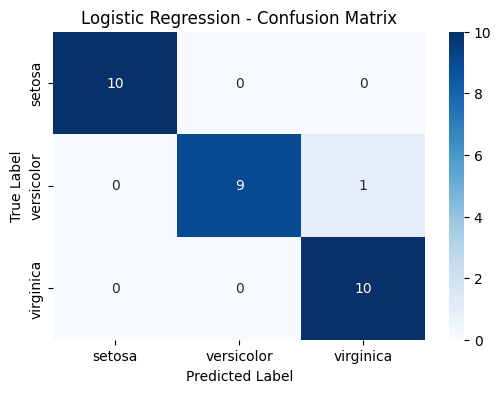

In [15]:
logistic_accuracy = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_logistic
)

===== Random Forest Classifier =====
Accuracy: 0.9000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



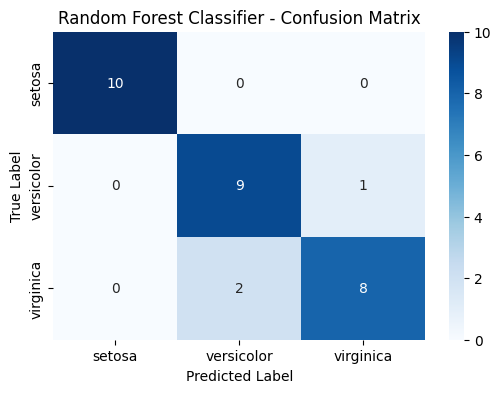

In [16]:
rf_accuracy = evaluate_model(
    "Random Forest Classifier",
    y_test,
    y_pred_rf
)

In [17]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [logistic_accuracy, rf_accuracy]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy
0,Logistic Regression,0.966667
1,Random Forest,0.900000


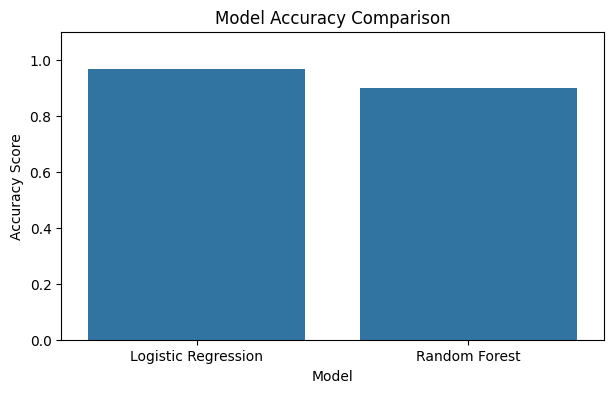

In [18]:
plt.figure(figsize=(7, 4))
sns.barplot(data=results, x="Model", y="Accuracy")

plt.title("Model Accuracy Comparison")
plt.ylim(0, 1.1)
plt.ylabel("Accuracy Score")
plt.show()

In [ ]:
# Select the best model based on accuracy
import joblib
import os


if logistic_accuracy >= rf_accuracy:
    best_model = logistic_model
    best_model_name = "Logistic Regression"
else:
    best_model = rf_model
    best_model_name = "Random Forest Classifier"

print(f"Best Model: {best_model_name}")

# Create the models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained model
model_path = "D:\OIBSIP\DataScience-L1-IrisFlowerClassification\models/iris_model.pkl"

joblib.dump(best_model, model_path)

print(f"Model saved successfully at: {model_path}")

Best Model: Logistic Regression
Model saved successfully at: D:\OIBSIP\DataScience-L1-IrisFlowerClassification\models/iris_model.pkl


# Conclusion

In this project, two machine learning classification models were trained to predict Iris flower species based on their physical measurements.

Both Logistic Regression and Random Forest Classifier achieved strong performance on the test dataset. The models were evaluated using accuracy, confusion matrices, precision, recall, and F1-score.

Based on the evaluation results, the best-performing model was selected according to its accuracy and overall classification performance. The results demonstrate that the Iris dataset can be effectively classified using machine learning techniques.

The exploratory data analysis also showed that petal length and petal width are among the most important features for distinguishing between Iris species.